# SMS Spam Detection with PyTorch

A complete machine learning project for classifying SMS messages as spam or legitimate (ham) using a neural network built with PyTorch.

## Setup and Installation

In [1]:
import torch
import sys

print("=" * 50)
print("Vérification de l'installation PyTorch")
print("=" * 50)

# Informations de base
print(f"Version de Python : {sys.version.split()[0]}")
print(f"Version de PyTorch : {torch.__version__}")

# Informations CUDA
print(f"\nCUDA disponible : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Version CUDA : {torch.version.cuda}")
    print(f"Version cuDNN : {torch.backends.cudnn.version()}")
    print(f"Nombre de GPU : {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i} : {torch.cuda.get_device_name(i)}")
        props = torch.cuda.get_device_properties(i)
        print(f"    Mémoire : {props.total_memory / 1024**3:.1f} Go")

# Informations MPS (Apple Silicon)
print(f"\nMPS disponible (Apple Silicon) : {torch.backends.mps.is_available()}")

# Test rapide
print(f"\nTest rapide - Création de tenseur : {torch.tensor([1, 2, 3])}")
print("\nInstallation réussie !")

Vérification de l'installation PyTorch
Version de Python : 3.13.0
Version de PyTorch : 2.7.1+cpu

CUDA disponible : False

MPS disponible (Apple Silicon) : False

Test rapide - Création de tenseur : tensor([1, 2, 3])

Installation réussie !


In [2]:
# PyTorch principal - opérations sur les tenseurs
import torch

# Module de réseaux de neurones
import torch.nn as nn

# API fonctionnelle (fonctions sans état)
import torch.nn.functional as F

# Algorithmes d'optimisation
import torch.optim as optim

# Utilitaires de chargement de données
from torch.utils.data import Dataset, DataLoader

# Bibliothèques compagnons courantes
import numpy as np
import matplotlib.pyplot as plt

print("Tous les modules importés avec succès !")
print(f"\nObjectif des modules :")
print(f"  torch : Opérations principales sur les tenseurs")
print(f"  torch.nn : Couches et modèles de réseaux de neurones")
print(f"  torch.nn.functional : Fonctions sans état (relu, softmax, etc.)")
print(f"  torch.optim : Optimiseurs (SGD, Adam, etc.)")
print(f"  torch.utils.data : Utilitaires de chargement de données")

Tous les modules importés avec succès !

Objectif des modules :
  torch : Opérations principales sur les tenseurs
  torch.nn : Couches et modèles de réseaux de neurones
  torch.nn.functional : Fonctions sans état (relu, softmax, etc.)
  torch.optim : Optimiseurs (SGD, Adam, etc.)
  torch.utils.data : Utilitaires de chargement de données


In [3]:
import torch

# Analyser les composants de version
version = torch.__version__
major, minor = version.split('.')[:2]

print(f"Version complète : {version}")
print(f"Version majeure : {major}")
print(f"Version mineure : {minor}")

# Vérifier la disponibilité des fonctionnalités
print(f"\nDisponibilité des fonctionnalités :")
print(f"  torch.compile (2.0+) : {hasattr(torch, 'compile')}")
print(f"  torch.cuda.amp : {hasattr(torch.cuda, 'amp')}")
print(f"  torch.jit : {hasattr(torch, 'jit')}")

# Configuration de compilation
print(f"\nConfiguration de compilation :")
print(f"  Build debug : {torch.version.debug}")
print(f"  CUDA compilé : {torch.version.cuda is not None}")

Version complète : 2.7.1+cpu
Version majeure : 2
Version mineure : 7

Disponibilité des fonctionnalités :
  torch.compile (2.0+) : True
  torch.cuda.amp : True
  torch.jit : True

Configuration de compilation :
  Build debug : False
  CUDA compilé : False


In [4]:
import pandas as pd
# Charger le dataset
df = pd.read_csv('D:\Semester4\DeepL\TP\spam.csv', encoding='latin-1')

# Le dataset Kaggle a plusieurs colonnes, on garde seulement v1 et v2
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Explorer les données
print("Dataset Overview:")
print(df.head(10))
print(f"\nDataset Size: {len(df)} messages")
print(f"\nClass Distribution:")
print(df['label'].value_counts())
print(f"\nSpam Percentage: {(df['label']=='spam').sum()/len(df)*100:.2f}%")
print(f"\n" + "="*60)
print(f"SPAM Examples:")
print(f"="*60)
print(df[df['label']=='spam']['message'].iloc[0])
print(f"\n" + "="*60)
print(f"HAM Examples (legitimate messages):")
print(f"="*60)
print(df[df['label']=='ham']['message'].iloc[0])

Dataset Overview:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
5  spam  FreeMsg Hey there darling it's been 3 week's n...
6   ham  Even my brother is not like to speak with me. ...
7   ham  As per your request 'Melle Melle (Oru Minnamin...
8  spam  WINNER!! As a valued network customer you have...
9  spam  Had your mobile 11 months or more? U R entitle...

Dataset Size: 5572 messages

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Spam Percentage: 13.41%

SPAM Examples:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

HAM Examples (legitimate me

<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:3: SyntaxWarning: invalid escape sequence '\S'
C:\Users\khadi\AppData\Local\Temp\ipykernel_26692\953542228.py:3: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv('D:\Semester4\DeepL\TP\spam.csv', encoding='latin-1')


## Exploratory Data Analysis

A comprehensive analysis to understand the characteristics of spam vs legitimate messages.

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration de style pour les visualisations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("EDA modules imported successfully!")


EDA modules imported successfully!


In [6]:
### Dataset Overview

# Load the dataset
df = pd.read_csv('spam.csv', encoding='latin-1')

# Garder seulement les colonnes pertinentes
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print("=" * 70)
print("GENERAL INFORMATION")
print("="*70)
print(f"\nDataset Dimensions:")
print(f"   Number of rows: {df.shape[0]}")
print(f"   Number of columns: {df.shape[1]}")

print(f"\nData Types:")
print(df.dtypes)

print(f"\nMissing Values:")
print(df.isnull().sum())

print(f"\nFirst rows of dataset:")
print(df.head())

print(f"\nLast rows of dataset:")
print(df.tail())

GENERAL INFORMATION

Dataset Dimensions:
   Number of rows: 5572
   Number of columns: 2

Data Types:
label      object
message    object
dtype: object

Missing Values:
label      0
message    0
dtype: int64

First rows of dataset:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Last rows of dataset:
     label                                            message
5567  spam  This is the 2nd time we have tried 2 contact u...
5568   ham              Will Ì_ b going to esplanade fr home?
5569   ham  Pity, * was in mood for that. So...any other s...
5570   ham  The guy did some bitching but I acted like i'd...
5571   ham                         Rofl. Its true to its name



CLASS DISTRIBUTION

Number of messages per class:
label
ham     4825
spam     747
Name: count, dtype: int64

Percentages:
   HAM: 86.59%
   SPAM: 13.41%


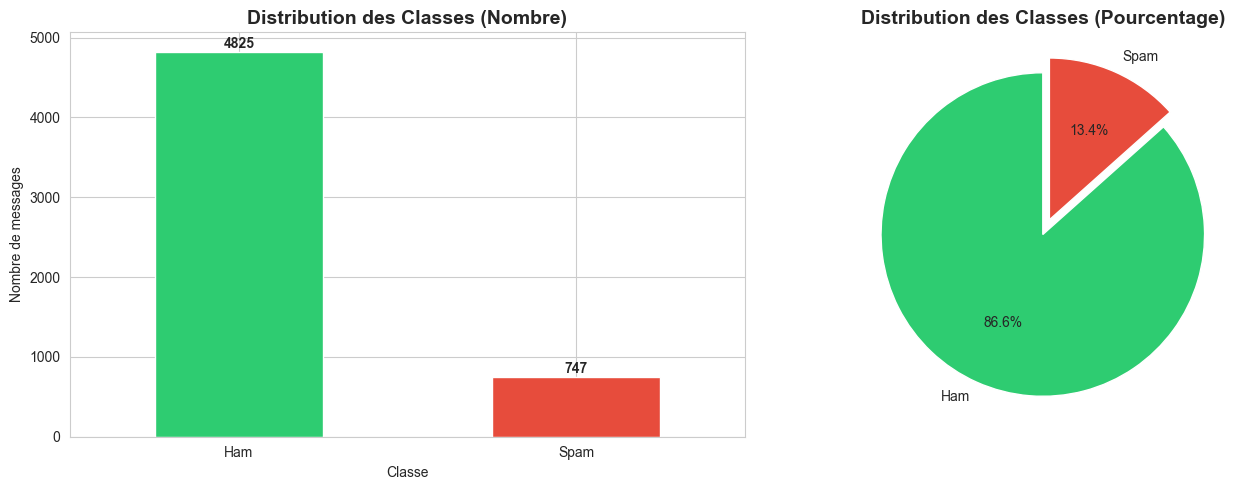


Observation: The dataset is IMBALANCED - 13.4% spam vs 86.6% ham


In [7]:
### Class Distribution

print("\n" + "="*70)
print("CLASS DISTRIBUTION")
print("="*70)

# Count the classes
class_counts = df['label'].value_counts()
print(f"\nNumber of messages per class:")
print(class_counts)

# Percentages
percentages = df['label'].value_counts(normalize=True) * 100
print(f"\nPercentages:")
for label, pct in percentages.items():
    print(f"   {label.upper()}: {pct:.2f}%")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
colors = ['#2ecc71', '#e74c3c']  # green for ham, red for spam
class_counts.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Distribution des Classes (Nombre)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre de messages')
axes[0].set_xticklabels(['Ham', 'Spam'], rotation=0)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Ham', 'Spam'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.1))
axes[1].set_title('Distribution des Classes (Pourcentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nObservation: The dataset is IMBALANCED - {percentages['spam']:.1f}% spam vs {percentages['ham']:.1f}% ham")

Message Statistics:

      message_length                                                           \
               count        mean        std   min    25%    50%    75%    max   
label                                                                           
ham           4825.0   71.023627  58.016023   2.0   33.0   52.0   92.0  910.0   
spam           747.0  138.866131  29.183082  13.0  132.5  149.0  157.0  224.0   

      word_count                                                      
           count       mean        std  min   25%   50%   75%    max  
label                                                                 
ham       4825.0  14.200622  11.424511  1.0   7.0  11.0  19.0  171.0  
spam       747.0  23.851406   5.811898  2.0  22.0  25.0  28.0   35.0  


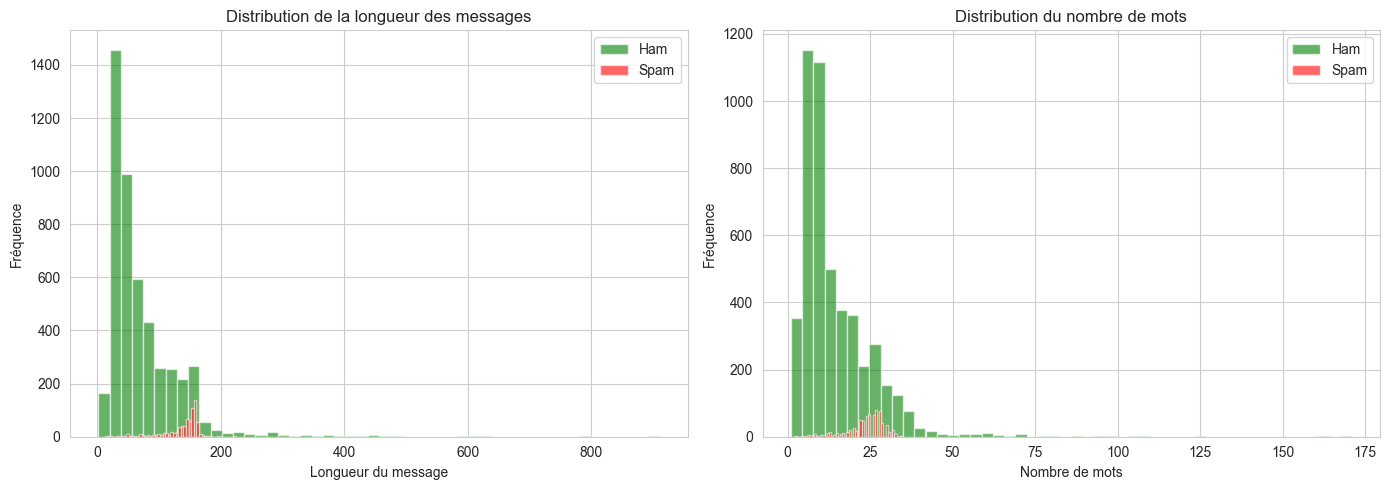

Observation: Spam messages are generally longer!


In [8]:
# Statistiques sur les messages
df['message_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

print("Message Statistics:\n")
print(df.groupby('label')[['message_length', 'word_count']].describe())

# Visualisation de la distribution des longueurs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Longueur des messages
df[df['label']=='ham']['message_length'].hist(bins=50, alpha=0.6, label='Ham', ax=axes[0], color='green')
df[df['label']=='spam']['message_length'].hist(bins=50, alpha=0.6, label='Spam', ax=axes[0], color='red')
axes[0].set_xlabel('Longueur du message')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de la longueur des messages')
axes[0].legend()

# Nombre de mots
df[df['label']=='ham']['word_count'].hist(bins=50, alpha=0.6, label='Ham', ax=axes[1], color='green')
df[df['label']=='spam']['word_count'].hist(bins=50, alpha=0.6, label='Spam', ax=axes[1], color='red')
axes[1].set_xlabel('Nombre de mots')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution du nombre de mots')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Observation: Spam messages are generally longer!")

## Data Preparation and Preprocessing

Prepare the data for training: split into train/validation/test sets and vectorize text using Bag-of-Words.

In [9]:
# Convertir les labels en nombres (ham=0, spam=1)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# Split train/validation/test (70/15/15)
X = df['message']
y = df['label_num']

# Premier split: train + val (85%) et test (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Deuxième split: train (82% du total) et val (18% du reste = ~15% du total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=42, stratify=y_train_val
)

print(f"Data Split:")
print(f"   Train set: {len(X_train)} messages ({len(X_train)/len(df)*100:.1f}%)")
print(f"   Validation set: {len(X_val)} messages ({len(X_val)/len(df)*100:.1f}%)")
print(f"   Test set: {len(X_test)} messages ({len(X_test)/len(df)*100:.1f}%)")

# Vectorization with Bag-of-Words
print(f"\nVectorization in progress...")
vectorizer = CountVectorizer(
    max_features=3000,      # Top 3000 mots
    stop_words='english',   # Retirer les stop words
    ngram_range=(1, 2),     # Utiliser unigrams et bigrams
    min_df=2                # Ignorer les mots qui apparaissent moins de 2 fois
)

X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_val_vec = vectorizer.transform(X_val).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

print(f"Vectorization completed!")
print(f"   Feature dimension: {X_train_vec.shape[1]}")
print(f"   Total vocabulary: {len(vectorizer.vocabulary_)} words")

# Afficher quelques features importantes
feature_names = vectorizer.get_feature_names_out()
print(f"Sample features (words/bigrams):")
print(f"   {list(feature_names[:20])}")

Data Split:
   Train set: 3902 messages (70.0%)
   Validation set: 834 messages (15.0%)
   Test set: 836 messages (15.0%)

Vectorization in progress...
Vectorization completed!
   Feature dimension: 3000
   Total vocabulary: 3000 words
Sample features (words/bigrams):
   ['00', '00 sub', '000', '000 bonus', '000 cash', '02', '02 06', '03', '03 2nd', '04', '05', '06', '06 03', '0800', '0800 542', '08000839402', '08000839402 call2optout', '08000930705', '08001950382', '0808']


In [10]:
class SMSDataset(Dataset):
    """
    Custom Dataset pour les SMS - Application du cours PyTorch

    Cette classe hérite de torch.utils.data.Dataset et implémente
    les 3 méthodes obligatoires: __init__, __len__, __getitem__
    """
    def __init__(self, features, labels):
        """
        Args:
            features (numpy.ndarray): Matrice des features vectorisées
            labels (pandas.Series): Labels (0=ham, 1=spam)
        """
        # Convertir en tenseurs PyTorch (Float pour X, Long pour y)
        self.X = torch.FloatTensor(features)
        self.y = torch.LongTensor(labels.values)

        print(f"    Dataset created: {len(self.y)} samples, {self.X.shape[1]} features")

    def __len__(self):
        """Returns the total number of samples"""
        return len(self.y)

    def __getitem__(self, idx):
        """
        Returns a sample (features, label) at index idx
        This method is called by the DataLoader
        """
        return self.X[idx], self.y[idx]

# Créer les datasets
print("Creating PyTorch datasets...")
train_dataset = SMSDataset(X_train_vec, y_train)
val_dataset = SMSDataset(X_val_vec, y_val)
test_dataset = SMSDataset(X_test_vec, y_test)

# Create DataLoaders
batch_size = 64
print(f"\nCreating DataLoaders (batch_size={batch_size})...")

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,           # Shuffle for each epoch
    num_workers=0           # 0 to avoid issues on certain systems
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(f"DataLoaders created!")
print(f"   Training batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

# Test the DataLoader
print(f"\nTesting DataLoader:")
for batch_features, batch_labels in train_loader:
    print(f"   Shape d'un batch de features: {batch_features.shape}")
    print(f"   Shape d'un batch de labels: {batch_labels.shape}")
    print(f"   Type des features: {batch_features.dtype}")
    print(f"   Type des labels: {batch_labels.dtype}")
    break  # Juste pour afficher un exemple

Creating PyTorch datasets...
    Dataset created: 3902 samples, 3000 features
    Dataset created: 834 samples, 3000 features
    Dataset created: 836 samples, 3000 features

Creating DataLoaders (batch_size=64)...
DataLoaders created!
   Training batches: 61
   Validation batches: 14
   Test batches: 14

Testing DataLoader:
   Shape d'un batch de features: torch.Size([64, 3000])
   Shape d'un batch de labels: torch.Size([64])
   Type des features: torch.float32
   Type des labels: torch.int64


## Data Loading and PyTorch Datasets

Create custom PyTorch Dataset and DataLoader objects for efficient batch processing.

In [11]:
class SpamClassifierMLP(nn.Module):
    """
    Multi-Layer Perceptron pour classification binaire

    Architecture:
        Input (3000) → FC1 (256) → ReLU → Dropout(0.5)
        → FC2 (128) → ReLU → Dropout(0.3)
        → FC3 (64) → ReLU → Dropout(0.2)
        → Output (2)
    """
    def __init__(self, input_size, hidden1=256, hidden2=128, hidden3=64):
        super(SpamClassifierMLP, self).__init__()

        # Première couche cachée
        self.fc1 = nn.Linear(input_size, hidden1)
        self.bn1 = nn.BatchNorm1d(hidden1)  # Batch normalization
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.5)

        # Deuxième couche cachée
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.bn2 = nn.BatchNorm1d(hidden2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)

        # Troisième couche cachée
        self.fc3 = nn.Linear(hidden2, hidden3)
        self.bn3 = nn.BatchNorm1d(hidden3)
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(0.2)

        # Couche de sortie (2 classes: ham ou spam)
        self.fc4 = nn.Linear(hidden3, 2)

    def forward(self, x):
        """
        Forward pass - Application des transformations séquentielles
        """
        # Couche 1
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        # Couche 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        # Couche 3
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.dropout3(x)

        # Couche de sortie (pas de softmax, car CrossEntropyLoss l'inclut)
        x = self.fc4(x)

        return x

# Initialiser le modèle
input_size = X_train_vec.shape[1]
model = SpamClassifierMLP(input_size)

print("Model Architecture:")
print("="*70)
print(model)
print("="*70)

# Calculate number of parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel Statistics:")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

# Display size of each layer
print(f"\nSize of each layer:")
for name, param in model.named_parameters():
    print(f"   {name:30s} → Shape: {str(param.shape):20s} | Params: {param.numel():,}")

Model Architecture:
SpamClassifierMLP(
  (fc1): Linear(in_features=3000, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (dropout3): Dropout(p=0.2, inplace=False)
  (fc4): Linear(in_features=64, out_features=2, bias=True)
)

Model Statistics:
   Total parameters: 810,434
   Trainable parameters: 810,434

Size of each layer:
   fc1.weight                     → Shape: torch.Size([256, 3000]) | Params: 768,000
   fc1.bias                       → Shape: torch.Size([256])    | Params

## Model Architecture

Define the neural network architecture for spam classification.

In [12]:
# Hyperparamètres
learning_rate = 0.001
num_epochs = 20

# Loss et Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Pour sauvegarder l'historique
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

print("Starting training...\n")

for epoch in range(num_epochs):
    # ============ TRAINING ============
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (data, targets) in enumerate(train_loader):
        # Forward pass
        outputs = model(data)
        loss = criterion(outputs, targets)

        # Backward pass avec Autograd (c'est ici qu'on applique ce qu'on a vu !)
        optimizer.zero_grad()  # Reset les gradients
        loss.backward()         # Calcul automatique des gradients
        optimizer.step()        # Mise à jour des poids

        # Statistiques
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ============ VALIDATION ============
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Pas de calcul de gradients pour la validation
        for data, targets in test_loader:
            outputs = model(data)
            loss = criterion(outputs, targets)

            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    test_loss = test_loss / len(test_loader)
    test_acc = 100 * correct / total
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    # Affichage
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

print("\nTraining completed!")

Starting training...

Epoch [1/20] | Train Loss: 0.3369 | Train Acc: 89.08% | Test Loss: 0.1418 | Test Acc: 97.01%
Epoch [2/20] | Train Loss: 0.0934 | Train Acc: 98.67% | Test Loss: 0.0797 | Test Acc: 97.85%
Epoch [3/20] | Train Loss: 0.0492 | Train Acc: 99.21% | Test Loss: 0.0739 | Test Acc: 97.73%
Epoch [4/20] | Train Loss: 0.0342 | Train Acc: 99.31% | Test Loss: 0.0738 | Test Acc: 98.09%
Epoch [5/20] | Train Loss: 0.0185 | Train Acc: 99.67% | Test Loss: 0.0799 | Test Acc: 98.09%
Epoch [6/20] | Train Loss: 0.0187 | Train Acc: 99.56% | Test Loss: 0.0726 | Test Acc: 98.33%
Epoch [7/20] | Train Loss: 0.0114 | Train Acc: 99.79% | Test Loss: 0.0838 | Test Acc: 98.21%
Epoch [8/20] | Train Loss: 0.0107 | Train Acc: 99.74% | Test Loss: 0.0874 | Test Acc: 97.97%
Epoch [9/20] | Train Loss: 0.0099 | Train Acc: 99.77% | Test Loss: 0.0869 | Test Acc: 98.09%
Epoch [10/20] | Train Loss: 0.0155 | Train Acc: 99.46% | Test Loss: 0.0903 | Test Acc: 97.97%
Epoch [11/20] | Train Loss: 0.0170 | Train Acc:

## Training and Evaluation

Train the model with backpropagation and evaluate performance on validation and test sets.

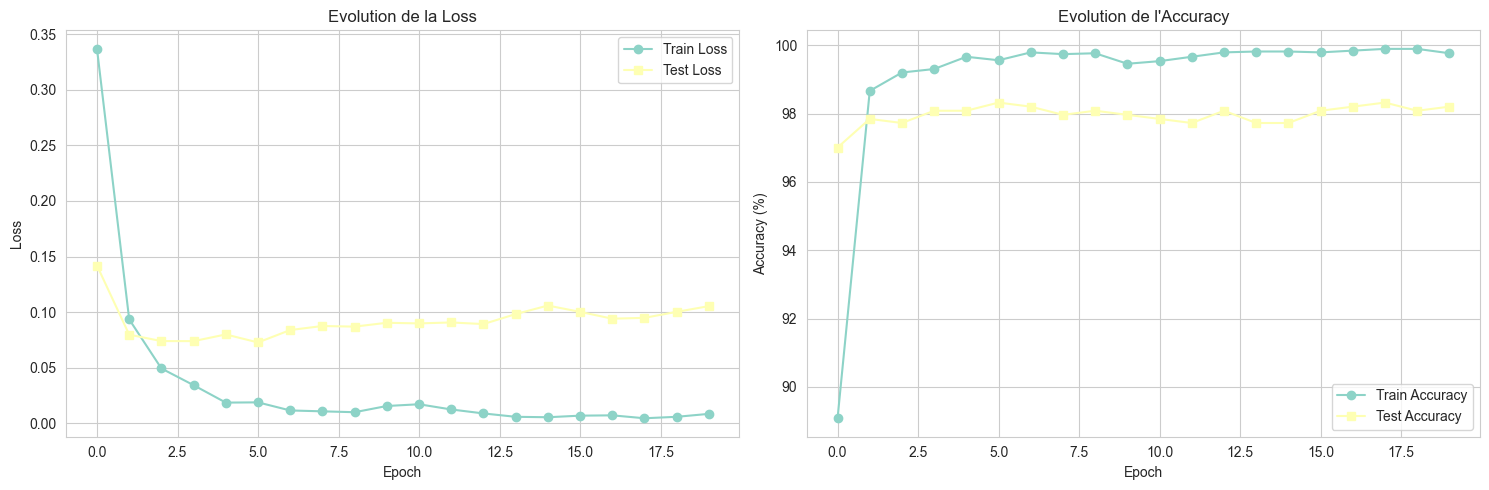

In [13]:
# Créer la figure avec 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Loss curves
ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(test_losses, label='Test Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Evolution de la Loss')
ax1.legend()
ax1.grid(True)

# Plot 2: Accuracy curves
ax2.plot(train_accuracies, label='Train Accuracy', marker='o')
ax2.plot(test_accuracies, label='Test Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Evolution de l\'Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Results and Visualization

Visualize training progress and model performance metrics.

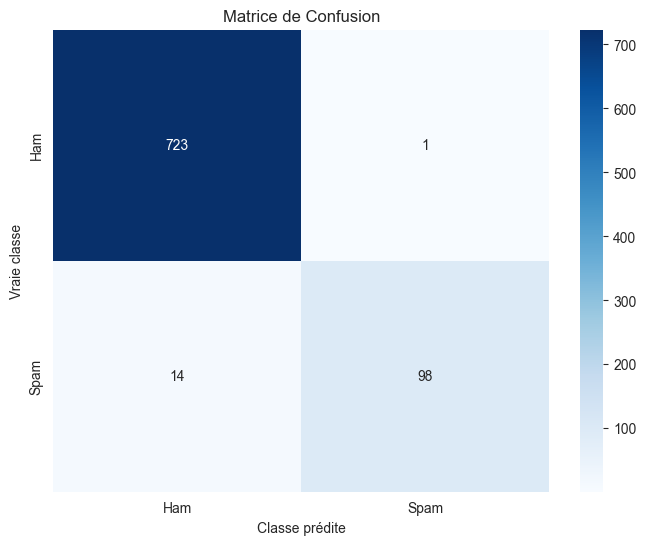


Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       724
        Spam       0.99      0.88      0.93       112

    accuracy                           0.98       836
   macro avg       0.99      0.94      0.96       836
weighted avg       0.98      0.98      0.98       836



In [14]:
from sklearn.metrics import confusion_matrix, classification_report

# Prédictions sur le test set
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for data, targets in test_loader:
        outputs = model(data)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.numpy())
        all_targets.extend(targets.numpy())

# Matrice de confusion
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.title('Matrice de Confusion')
plt.show()

# Rapport de classification
print("\nClassification Report:")
print(classification_report(all_targets, all_preds,
                          target_names=['Ham', 'Spam']))

In [15]:
def predict_message(message, model, vectorizer):
    """Prédire si un message est spam ou ham"""
    # Vectoriser le message
    message_vec = vectorizer.transform([message]).toarray()
    message_tensor = torch.FloatTensor(message_vec)

    # Prédiction
    model.eval()
    with torch.no_grad():
        output = model(message_tensor)
        probabilities = torch.softmax(output, dim=1)
        _, predicted = torch.max(output, 1)

    label = "SPAM" if predicted.item() == 1 else "HAM"
    confidence = probabilities[0][predicted.item()].item() * 100

    return label, confidence

# Tester quelques exemples
test_messages = [
    "Congratulations! You've won a free iPhone. Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT! Your account will be closed. Call this number immediately!",
    "Can you pick up some milk on your way home?"
]

print("Testing on new messages:\n")
for msg in test_messages:
    label, conf = predict_message(msg, model, vectorizer)
    print(f"Message: {msg[:60]}...")
    print(f"→ Prédiction: {label} (Confiance: {conf:.2f}%)\n")

Testing on new messages:

Message: Congratulations! You've won a free iPhone. Click here to cla...
→ Prédiction: SPAM (Confiance: 74.23%)

Message: Hey, are we still meeting for lunch tomorrow?...
→ Prédiction: HAM (Confiance: 99.99%)

Message: URGENT! Your account will be closed. Call this number immedi...
→ Prédiction: HAM (Confiance: 99.98%)

Message: Can you pick up some milk on your way home?...
→ Prédiction: HAM (Confiance: 99.99%)



In [16]:
#evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [17]:
accuracy = accuracy_score(all_targets, all_preds)
precision = precision_score(all_targets, all_preds)
recall = recall_score(all_targets, all_preds)
f1 = f1_score(all_targets, all_preds)

In [18]:
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9821
Precision: 0.9899
Recall: 0.8750
F1 Score: 0.9289


In [19]:
#mae rmse wmpae mape metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [20]:
mae = mean_absolute_error(all_targets, all_preds)
rmse = np.sqrt(mean_squared_error(all_targets, all_preds))

In [21]:
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Mean Absolute Error (MAE): 0.0179
Root Mean Squared Error (RMSE): 0.1339
